# Chimeric Spectra Analysis (PXD037527)

This notebook analyzes chimeric spectra by:
1. Loading all `psm.tsv` files from FragPipe output
2. Counting PSMs per spectrum
3. Identifying chimeric spectra (≥2 PSMs per spectrum)
4. Visualizing the distribution

**Datasets analyzed:**
- `02ng_30m_12mz/fragpipe_mbr`
- `1.6-48mz_30m/fragpipe`

## Setup

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Configuration

In [2]:
# Define paths
ROOT = Path('/Users/aminborqal/Documents/Uantwerpen/Research Internship/phase1/PXD037527')

DATASET_PATHS = [
    ROOT / '02ng_30m_12mz' / 'fragpipe_mbr',
    ROOT / '1.6-48mz_30m' / 'fragpipe'
]

# Columns to retain from PSM files
COLUMNS_TO_KEEP = [
    'Spectrum', 'Peptide', 'Charge', 'Hyperscore', 'Purity', 'Intensity',
    'SpectralSim', 'RTScore', 'Expectation', 'Nextscore',
    'Protein', 'Gene', 'Protein Description'
]

## Data Loading

In [3]:
# Find all psm.tsv files
psm_files = []

for base_path in DATASET_PATHS:
    if base_path.exists():
        files = sorted(base_path.rglob('psm.tsv'))
        psm_files.extend(files)
        print(f"Found {len(files)} files in {base_path.name}")
    else:
        print(f"⚠️  Path not found: {base_path}")

print(f"\nTotal PSM files found: {len(psm_files)}")

if len(psm_files) == 0:
    raise ValueError("No psm.tsv files found. Please check DATASET_PATHS.")

Found 28 files in fragpipe_mbr
Found 59 files in fragpipe

Total PSM files found: 87


In [4]:
# Load and concatenate all PSM files
print("Loading PSM files...")

dataframes = []
for psm_file in psm_files:
    df = pd.read_csv(psm_file, sep='\t')
    df['run'] = psm_file.parent.name  # Add run identifier
    dataframes.append(df)

# Concatenate all dataframes
psm_raw = pd.concat(dataframes, ignore_index=True)

print(f"Loaded {len(psm_raw):,} PSMs from {len(psm_files)} files")
print(f"Shape: {psm_raw.shape}")

Loading PSM files...


/var/folders/r4/hh357kg10tl7tyxysctqkm100000gn/T/ipykernel_19226/2622786424.py:6: DtypeWarning: Columns (37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(psm_file, sep='\t')


Loaded 2,246,503 PSMs from 87 files
Shape: (2246503, 40)


## Data Cleaning

In [5]:
# Remove duplicate columns (if any)
psm = psm_raw.loc[:, ~psm_raw.columns.duplicated()]

# Select only columns that exist in the dataframe
columns_to_select = [col for col in COLUMNS_TO_KEEP if col in psm.columns] + ['run']
psm = psm[columns_to_select]

print(f"Selected columns: {psm.columns.tolist()}")
print(f"Final shape: {psm.shape}")
print("\nFirst few rows:")
psm.head()

Selected columns: ['Spectrum', 'Peptide', 'Charge', 'Hyperscore', 'Purity', 'Intensity', 'SpectralSim', 'RTScore', 'Expectation', 'Nextscore', 'Protein', 'Gene', 'Protein Description', 'run']
Final shape: (2246503, 14)

First few rows:


,Spectrum,Peptide,Charge,Hyperscore,Purity,Intensity,SpectralSim,RTScore,Expectation,Nextscore,Protein,Gene,Protein Description,run
0,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,24.5576,0.0,820013.60,0.9802,0.1229,0.000071,24.5576,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1
1,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,22.7800,0.0,645029.56,0.9483,0.1539,0.000418,22.7800,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1
2,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,15.7807,0.0,812365.80,0.8095,0.1889,0.458086,15.7807,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1
3,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,HAVSEGTK,2,11.7465,0.0,790822.00,0.7724,0.2803,25.881600,11.7465,sp|O60814|H2B1K_HUMAN,H2BC12,Histone H2B type 1-K,02ngK5_1
4,Ex_AuLC1_30m_2D19_3_20um30cm_SPE50_15118120_OT...,EDTEEHHLR,3,11.2393,0.0,0.00,0.6858,1.5295,42.979740,11.2393,sp|P22626|ROA2_HUMAN,HNRNPA2B1,Heterogeneous nuclear ribonucleoproteins A2/B1,02ngK5_1


## Chimeric Spectra Analysis

In [10]:
# Count PSMs per spectrum
psm_counts = psm.groupby('Spectrum').size()


In [11]:
# Calculate full distribution (including zeros for missing values)
max_psm = psm_counts.max()
distribution = psm_counts.value_counts().sort_index()
distribution_full = distribution.reindex(range(1, max_psm + 1), fill_value=0)

print("\nPSM Distribution (PSMs per spectrum):")
print("=" * 40)
print(distribution_full.to_string())
print("=" * 40)


PSM Distribution (PSMs per spectrum):
1     469509
2     370250
3     144442
4     102516
5      19368
6      12197
7        260
8       2263
9         42
10       278


## Visualization

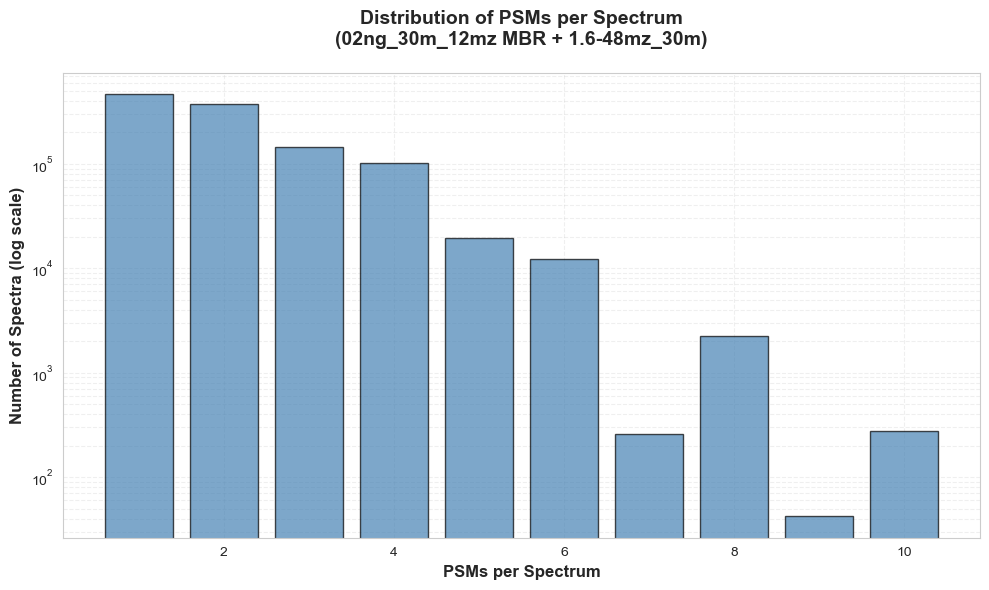


Note: 651,616 spectra (58.12%) are chimeric (≥2 PSMs)


In [13]:
# Plot distribution of PSMs per spectrum
fig, ax = plt.subplots(figsize=(10, 6))

# Get distribution data
dist_data = psm_counts.value_counts().sort_index()

# Create bar plot
ax.bar(dist_data.index, dist_data.values, color='steelblue', edgecolor='black', alpha=0.7)

# Formatting
ax.set_xlabel('PSMs per Spectrum', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Spectra (log scale)', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.set_title('Distribution of PSMs per Spectrum\n(02ng_30m_12mz MBR + 1.6-48mz_30m)', 
             fontsize=14, fontweight='bold', pad=20)

# Add grid
ax.grid(True, which='both', alpha=0.3, linestyle='--')


plt.tight_layout()
plt.show()

print(f"\nNote: {chimeric_2plus:,} spectra ({100*chimeric_2plus/total_spectra:.2f}%) are chimeric (≥2 PSMs)")

## Export Results

In [16]:
# Create summary dataframe
summary_df = pd.DataFrame({
    'PSMs_per_spectrum': psm_counts.value_counts().sort_index().index,
    'Number_of_spectra': psm_counts.value_counts().sort_index().values
})

print("Summary table:")
print(summary_df.head(20))

# Optionally save to CSV
# output_path = ROOT / 'chimeric_analysis_summary.csv'
# summary_df.to_csv(output_path, index=False)
# print(f"\nSummary saved to: {output_path}")

Summary table:
   PSMs_per_spectrum  Number_of_spectra
0                  1             469509
1                  2             370250
2                  3             144442
3                  4             102516
4                  5              19368
5                  6              12197
6                  7                260
7                  8               2263
8                  9                 42
9                 10                278
